<a href="https://colab.research.google.com/github/Razvan8458/Cat-or-Dog-classifier/blob/main/Copy_of_fcc_cat_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
  # This command only in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, InputLayer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
# Get project files
!wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

!unzip cats_and_dogs.zip

PATH = 'cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

# Variables for pre-processing and training.
batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.60.jpg  
  inflating: cats_and_dogs/train/dogs/dog.858.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.858.jpg  
  inflating: cats_and_dogs/train/dogs/dog.680.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.680.jpg  
  inflating: cats_and_dogs/train/dogs/dog.694.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.694.jpg  
  inflating: cats_and_dogs/train/dogs/dog.864.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.864.jpg  
  inflating: cats_and_dogs/train/dogs/dog.870.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.870.jpg  
  inflating: cats_and_dogs/train/dogs/dog.871.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.871.jpg  
  inflating: cats_and_dogs/train/dogs/dog.865.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.865.jpg  
  inflating: cats_and_dogs/train/dogs/dog.695.jpg  
  inflating: __MACOSX/cats_and

In [ ]:
# 3
train_image_generator = ImageDataGenerator(rescale = 1./255)
validation_image_generator = ImageDataGenerator(rescale = 1./255)
test_image_generator = ImageDataGenerator(rescale = 1./255)

train_data_gen = train_image_generator.flow_from_directory(directory = train_dir, batch_size = batch_size, target_size = (IMG_HEIGHT, IMG_WIDTH), class_mode = 'binary')
val_data_gen = validation_image_generator.flow_from_directory(directory = validation_dir, batch_size = batch_size, target_size = (IMG_HEIGHT, IMG_WIDTH), class_mode = 'binary')
#!mkdir cats_and_dogs/test/images
#!mv cats_and_dogs/test/*.jpg cats_and_dogs/test/images
test_data_gen = test_image_generator.flow_from_directory(directory = test_dir, batch_size = batch_size, target_size = (IMG_HEIGHT, IMG_WIDTH), class_mode = 'binary', shuffle = False)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 50 images belonging to 1 classes.


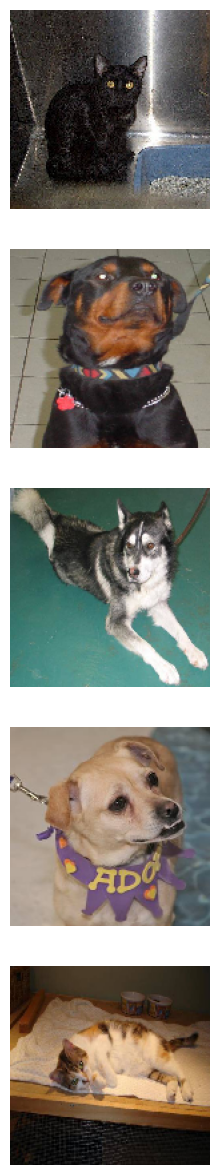

In [ ]:
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])


In [ ]:
# 5
train_image_generator = ImageDataGenerator(rescale = 1./255, rotation_range = 30, horizontal_flip = True, zoom_range = 0.2, shear_range = 0.05, brightness_range = [0.7, 1.3], channel_shift_range = 0.05)


Found 2000 images belonging to 2 classes.


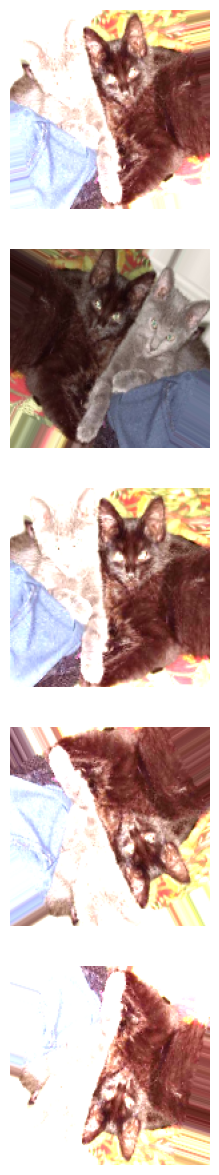

In [ ]:
# 6
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [ ]:
# 7
model = Sequential(

    [InputLayer(shape = [150, 150, 3]),
    Conv2D(filters = 16, kernel_size = 3, activation = 'relu'),
    Conv2D(filters = 16, kernel_size = 3, activation = 'relu'),
    MaxPooling2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 3, activation = 'relu'),
    MaxPooling2D(pool_size = 2),
    Conv2D(filters = 64, kernel_size = 3, activation = 'relu'),
    MaxPooling2D(pool_size = 2),
    Flatten(),
    Dense(256, activation = 'relu'),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'sigmoid')]

)

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])






model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 146, 146, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 73, 73, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 71, 71, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 35, 35, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 33, 33, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,228,721 (16.13 MB)

 Trainable params: 4,228,721 (16.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 8
history = model.fit(x = train_data_gen, steps_per_epoch = 16, epochs = epochs, validation_data = val_data_gen, validation_steps = 8)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 94s 6s/step - accuracy: 0.5048 - loss: 0.7033 - val_accuracy: 0.5070 - val_loss: 0.6917
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 140s 6s/step - accuracy: 0.5348 - loss: 0.6919 - val_accuracy: 0.5740 - val_loss: 0.6892
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.5329 - loss: 0.6904 - val_accuracy: 0.5500 - val_loss: 0.6880
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy: 0.5352 - loss: 0.6901 - val_accuracy: 0.5990 - val_loss: 0.6815
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 91s 6s/step - accuracy: 0.5522 - loss: 0.6857 - val_accuracy: 0.5920 - val_loss: 0.6688
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 91s 6s/step - accuracy: 0.5906 - loss: 0.6703 - val_accuracy: 0.6120 - val_loss: 0.6597
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 89s 6s/step - accuracy: 0.5853 - loss: 0.6743 - val_accuracy: 0.6280 - val_loss: 0.6562
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 91s 6s/step - accuracy: 0.6126 - loss: 0.6660 - val_accuracy: 0.6470 - val_los

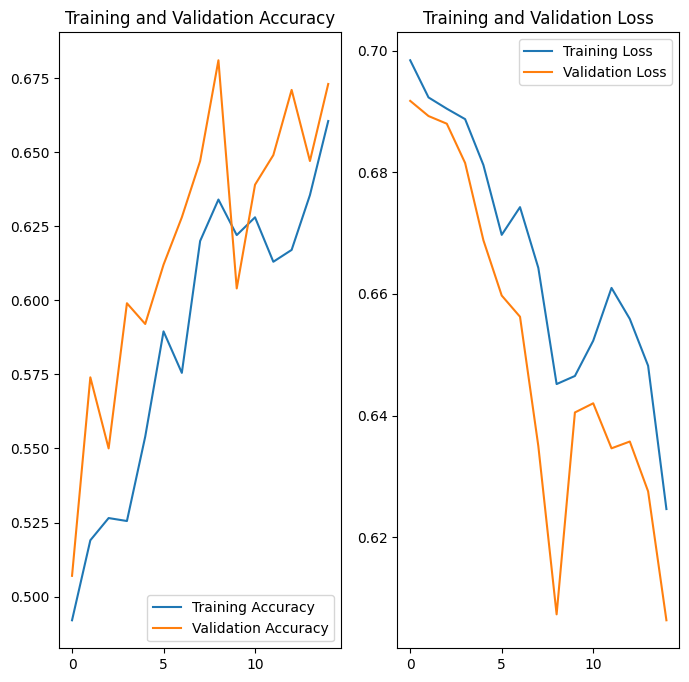

In [ ]:
# 9
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# 11
answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
            0, 0, 0, 0, 0, 0]

correct = 0
probabilities = model.predict(test_data_gen)
for probability, answer in zip(probabilities, answers):
  if round(probability[0]) == answer:
    correct +=1

percentage_identified = (correct / len(answers)) * 100

passed_challenge = percentage_identified >= 63

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if passed_challenge:
  print("You passed the challenge!")
else:
  print("You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
Your model correctly identified 62.0% of the images of cats and dogs.
You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!
